
A1: Feature Data Types:
  ID                   : Identifier
  Year_Birth           : Ratio
  Education            : Ordinal
  Marital_Status       : Nominal
  Income               : Ratio
  Kidhome              : Ordinal
  Teenhome             : Ordinal
  Dt_Customer          : Nominal
  Recency              : Ratio
  MntWines             : Ratio
  MntFruits            : Ratio
  MntMeatProducts      : Ratio
  MntFishProducts      : Ratio
  MntSweetProducts     : Ratio
  MntGoldProds         : Ratio
  NumDealsPurchases    : Ratio
  NumWebPurchases      : Ratio
  NumCatalogPurchases  : Ratio
  NumStorePurchases    : Ratio
  NumWebVisitsMonth    : Ratio
  AcceptedCmp3         : Ordinal
  AcceptedCmp4         : Ordinal
  AcceptedCmp5         : Ordinal
  AcceptedCmp1         : Ordinal
  AcceptedCmp2         : Ordinal
  Complain             : Ordinal
  Z_CostContact        : Ordinal
  Z_Revenue            : Ordinal
  Response             : Ordinal

A2: Encoding Functions - Created successfu

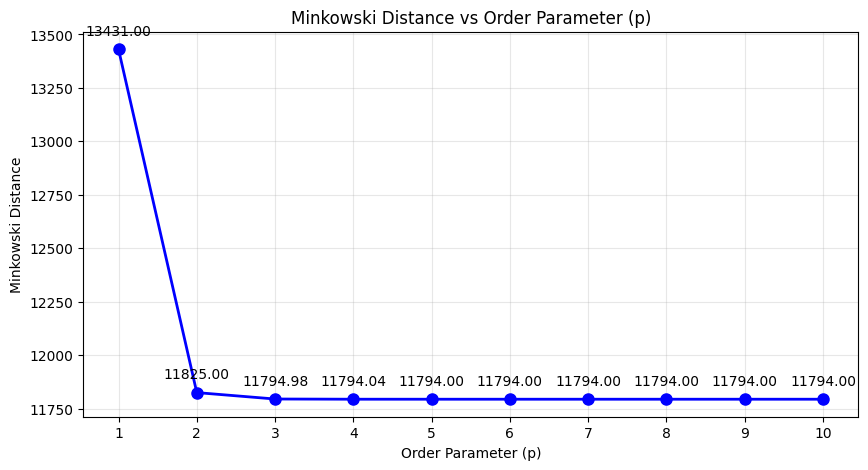


A6: Comparison with SciPy implementation:
  p=1: Custom=13431.000000, SciPy=13431.000000, Diff=0.0000000000
  p=2: Custom=11825.004228, SciPy=11825.004228, Diff=0.0000000000
  p=3: Custom=11794.975787, SciPy=11794.975787, Diff=0.0000000000
  p=5: Custom=11794.001454, SciPy=11794.001454, Diff=0.0000000000

A7: Vector Operations:
  Dot Product: 1912108121.0000
  Euclidean Norm of A: 71641.4572
  Euclidean Norm of B: 26719.7863
  Verification (np.dot): 1912108121.0000
  Verification (np.linalg.norm A): 71641.4572

A8: Statistics for first 5 numeric columns:
  Year_Birth           | Mean:    1968.81 | Std:      11.98
  Income               | Mean:   52247.25 | Std:   25173.08
  Kidhome              | Mean:       0.44 | Std:       0.54
  Teenhome             | Mean:       0.51 | Std:       0.54
  Recency              | Mean:      49.11 | Std:      28.96

A9: Comparison with NumPy functions:

  Year_Birth:
    Mean: Custom=1968.805804, NumPy=1968.805804
    Std:  Custom=11.984069, NumPy=11.

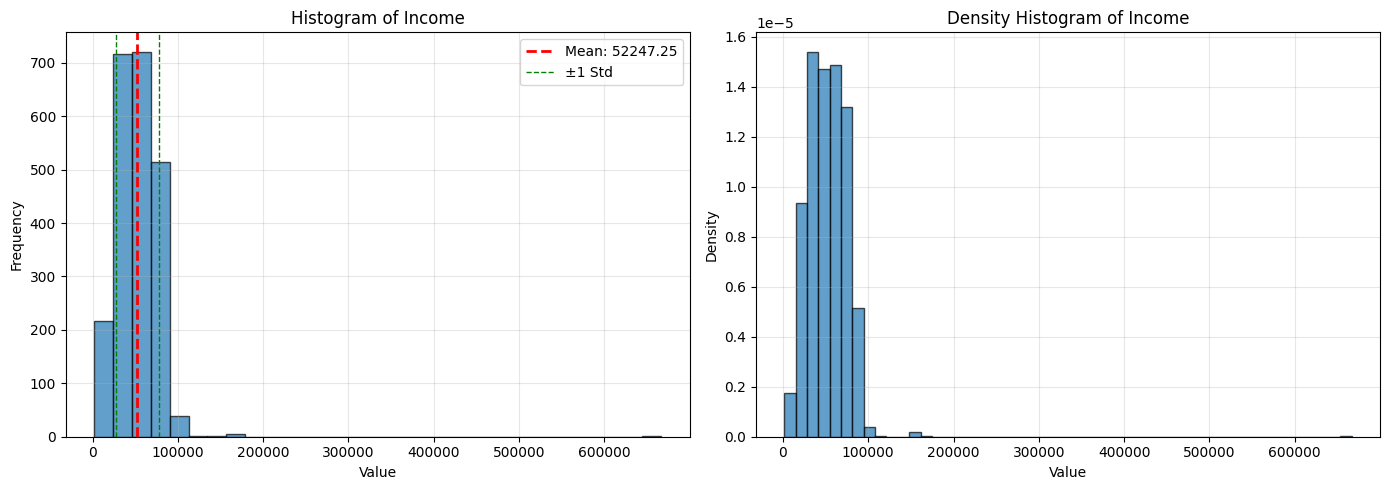


A11: K-Means Clustering:
  Using 2216 rows for clustering (removed 24 rows with NaN)
  K=2: Inertia = 39670.20
  K=3: Inertia = 36481.25
  K=4: Inertia = 33561.42
  K=5: Inertia = 32881.80
  K=6: Inertia = 31373.57
  K=7: Inertia = 29012.93


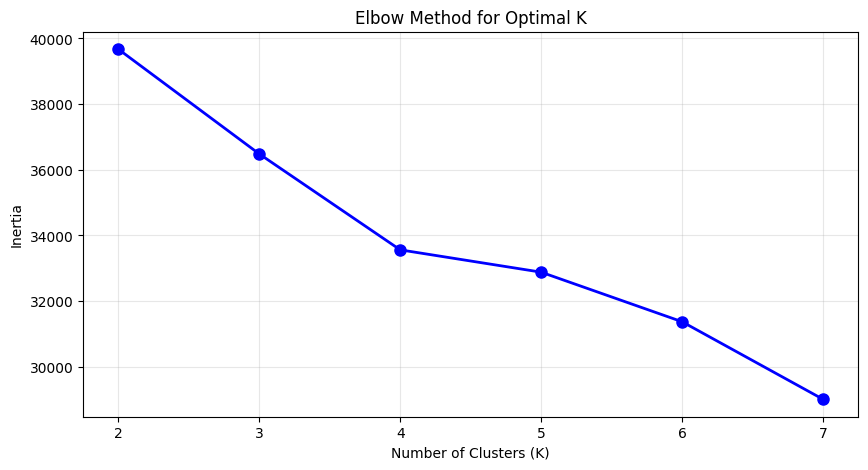


  Selecting K=3 as optimal number of clusters

  Cluster distribution:
    Cluster 0: 795 points (35.9%)
    Cluster 1: 1223 points (55.2%)
    Cluster 2: 198 points (8.9%)



In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


file_path = r"C:\Users\thanu\Downloads\Lab Session Data (1) (3).xlsx"
df = pd.read_excel(file_path, sheet_name='marketing_campaign')

# =============================================================================
# A1: Identify Feature Types
# =============================================================================

def identify_feature_types(df):
    feature_types = {}
    for column in df.columns:
        if column.lower() in ['id']:
            feature_types[column] = "Identifier"
            continue
        if pd.api.types.is_datetime64_any_dtype(df[column]):
            feature_types[column] = "Interval (Date)"
            continue
        if pd.api.types.is_numeric_dtype(df[column]):
            if pd.api.types.is_integer_dtype(df[column]):
                unique_vals = df[column].nunique()
                if unique_vals <= 10 and column not in ['Year_Birth']:
                    feature_types[column] = "Ordinal"
                else:
                    feature_types[column] = "Ratio" if df[column].min() >= 0 else "Interval"
            else:
                feature_types[column] = "Ratio" if df[column].min() >= 0 else "Interval"
        else:
            if column.lower() in ['education']:
                feature_types[column] = "Ordinal"
            elif column.lower() in ['marital_status']:
                feature_types[column] = "Nominal"
            else:
                feature_types[column] = "Nominal"
    return feature_types

feature_types = identify_feature_types(df)
print("\nA1: Feature Data Types:")
for feature, dtype in feature_types.items():
    print(f"  {feature:20} : {dtype}")

# =============================================================================
# A2: Encoding Functions
# =============================================================================

def label_encoding(series):
    unique_categories = sorted(series.astype(str).unique())
    mapping = {category: idx for idx, category in enumerate(unique_categories)}
    return np.array([mapping[str(val)] for val in series])

def one_hot_encoding(series):
    unique_categories = sorted(series.astype(str).unique())
    one_hot = np.zeros((len(series), len(unique_categories)), dtype=int)
    for i, val in enumerate(series):
        idx = np.where(np.array(unique_categories) == str(val))[0][0]
        one_hot[i, idx] = 1
    col_names = [f"{series.name}_{cat}" for cat in unique_categories]
    return pd.DataFrame(one_hot, columns=col_names)

print("\nA2: Encoding Functions - Created successfully")

# =============================================================================
# A3: Apply Encoding
# =============================================================================

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nA3: Categorical columns: {categorical_cols}")

df_encoded = df.copy()
for col in categorical_cols:
    if col in df.columns:
        df_encoded[f'{col}_label'] = label_encoding(df[col])
        one_hot_df = one_hot_encoding(df[col])
        df_encoded = pd.concat([df_encoded, one_hot_df], axis=1)

print(f"  Original shape: {df.shape}")
print(f"  Encoded shape: {df_encoded.shape}")
print(f"  Dimensionality increased by: {df_encoded.shape[1] - df.shape[1]} columns")

# =============================================================================
# A4: Minkowski Distance Function
# =============================================================================

def minkowski_distance(vector_a, vector_b, p):
    vector_a = np.array(vector_a, dtype=float)
    vector_b = np.array(vector_b, dtype=float)
    if len(vector_a) != len(vector_b):
        raise ValueError("Vectors must have same length")
    diff = np.abs(vector_a - vector_b)
    return np.sum(diff ** p) ** (1/p)

print("\nA4: Minkowski Distance Function - Test:")
test_a, test_b = np.array([1, 2, 3]), np.array([4, 5, 6])
print(f"  Manhattan (p=1): {minkowski_distance(test_a, test_b, 1):.4f}")
print(f"  Euclidean (p=2): {minkowski_distance(test_a, test_b, 2):.4f}")

# =============================================================================
# A5: Plot Minkowski Distance for p=1 to 10
# =============================================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['ID', 'Z_CostContact', 'Z_Revenue']]

vector_a = df[numeric_cols].iloc[0].values
vector_b = df[numeric_cols].iloc[1].values

p_values = range(1, 11)
distances = [minkowski_distance(vector_a, vector_b, p) for p in p_values]

print("\nA5: Minkowski Distance for p=1 to 10:")
for p, d in zip(p_values, distances):
    print(f"  p={p}: {d:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(p_values, distances, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Order Parameter (p)')
plt.ylabel('Minkowski Distance')
plt.title('Minkowski Distance vs Order Parameter (p)')
plt.grid(True, alpha=0.3)
plt.xticks(p_values)
for i, d in enumerate(distances):
    plt.annotate(f'{d:.2f}', (p_values[i], d), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

# =============================================================================
# A6: Compare with SciPy
# =============================================================================

print("\nA6: Comparison with SciPy implementation:")
for p in [1, 2, 3, 5]:
    custom_dist = minkowski_distance(vector_a, vector_b, p)
    scipy_dist = minkowski(vector_a, vector_b, p)
    diff = abs(custom_dist - scipy_dist)
    print(f"  p={p}: Custom={custom_dist:.6f}, SciPy={scipy_dist:.6f}, Diff={diff:.10f}")

# =============================================================================
# A7: Vector Operations
# =============================================================================

def dot_product(vector_a, vector_b):
    return np.sum(np.array(vector_a, dtype=float) * np.array(vector_b, dtype=float))

def euclidean_norm(vector):
    return np.sqrt(np.sum(np.array(vector, dtype=float) ** 2))

A = df[numeric_cols].iloc[2].values
B = df[numeric_cols].iloc[3].values

print("\nA7: Vector Operations:")
print(f"  Dot Product: {dot_product(A, B):.4f}")
print(f"  Euclidean Norm of A: {euclidean_norm(A):.4f}")
print(f"  Euclidean Norm of B: {euclidean_norm(B):.4f}")
print(f"  Verification (np.dot): {np.dot(A, B):.4f}")
print(f"  Verification (np.linalg.norm A): {np.linalg.norm(A):.4f}")

# =============================================================================
# A8: Mean, Variance, Standard Deviation Functions
# =============================================================================

def calculate_mean(data):
    data = np.array(data, dtype=float)
    return np.sum(data) / len(data)

def calculate_variance(data, ddof=0):
    data = np.array(data, dtype=float)
    mean = calculate_mean(data)
    return np.sum((data - mean) ** 2) / (len(data) - ddof)

def calculate_std_dev(data, ddof=0):
    return np.sqrt(calculate_variance(data, ddof))

def calculate_column_stats(df, columns=None):
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
        columns = [col for col in columns if col not in ['ID', 'Z_CostContact', 'Z_Revenue']]
    
    stats = {}
    for col in columns[:5]:
        data = df[col].dropna().values
        stats[col] = {
            'mean': calculate_mean(data),
            'variance': calculate_variance(data, ddof=1),
            'std_dev': calculate_std_dev(data, ddof=1)
        }
    return stats

numeric_stats = calculate_column_stats(df)
print("\nA8: Statistics for first 5 numeric columns:")
for col, stats in numeric_stats.items():
    print(f"  {col:20} | Mean: {stats['mean']:10.2f} | Std: {stats['std_dev']:10.2f}")

# =============================================================================
# A9: Compare with NumPy
# =============================================================================

print("\nA9: Comparison with NumPy functions:")
for col in list(numeric_stats.keys())[:3]:
    data = df[col].dropna().values
    print(f"\n  {col}:")
    print(f"    Mean: Custom={calculate_mean(data):.6f}, NumPy={np.mean(data):.6f}")
    print(f"    Std:  Custom={calculate_std_dev(data, ddof=1):.6f}, NumPy={np.std(data, ddof=1):.6f}")

# =============================================================================
# A10: Histogram Analysis
# =============================================================================

def plot_histogram_analysis(df, feature_name, bins=30):
    data = df[feature_name].dropna().values
    mean = calculate_mean(data)
    std_dev = calculate_std_dev(data, ddof=1)
    
    print(f"\nA10: Histogram Analysis for '{feature_name}':")
    print(f"  Samples: {len(data)}")
    print(f"  Mean: {mean:.2f}")
    print(f"  Std Dev: {std_dev:.2f}")
    print(f"  Min: {np.min(data):.2f}")
    print(f"  Max: {np.max(data):.2f}")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(data, bins=bins, edgecolor='black', alpha=0.7)
    ax1.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')
    ax1.axvline(mean - std_dev, color='green', linestyle='dashed', linewidth=1, label='±1 Std')
    ax1.axvline(mean + std_dev, color='green', linestyle='dashed', linewidth=1)
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Histogram of {feature_name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(data, bins=50, density=True, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('Density')
    ax2.set_title(f'Density Histogram of {feature_name}')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'Income' in df.columns:
    plot_histogram_analysis(df, 'Income', bins=30)
else:
    plot_histogram_analysis(df, numeric_cols[0], bins=30)

# =============================================================================
# A11: K-Means Algorithm (Fixed)
# =============================================================================

def kmeans_clustering(data, k, max_iterations=100, tolerance=1e-4):
    data = np.array(data, dtype=float)
    n_samples, n_features = data.shape
    
    # K-means++ initialization
    centroids = []
    first_idx = np.random.randint(n_samples)
    centroids.append(data[first_idx].copy())
    
    for _ in range(1, k):
        distances = np.zeros(n_samples)
        for i, point in enumerate(data):
            min_dist = np.min([np.sum((point - c) ** 2) for c in centroids])
            distances[i] = min_dist
        if np.sum(distances) > 0:
            probabilities = distances / np.sum(distances)
            next_idx = np.random.choice(n_samples, p=probabilities)
            centroids.append(data[next_idx].copy())
        else:
            next_idx = np.random.randint(n_samples)
            centroids.append(data[next_idx].copy())
    
    centroids = np.array(centroids)
    labels = np.zeros(n_samples, dtype=int)
    
    for iteration in range(max_iterations):
        for i, point in enumerate(data):
            distances = [np.sum((point - c) ** 2) for c in centroids]
            labels[i] = np.argmin(distances)
        
        new_centroids = np.zeros_like(centroids)
        for cluster in range(k):
            cluster_points = data[labels == cluster]
            if len(cluster_points) > 0:
                new_centroids[cluster] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[cluster] = centroids[cluster]
        
        centroid_shift = np.sum((new_centroids - centroids) ** 2)
        centroids = new_centroids
        if centroid_shift < tolerance:
            break
    
    return centroids, labels

def calculate_inertia(data, centroids, labels):
    data = np.array(data, dtype=float)
    inertia = 0
    for i, point in enumerate(data):
        inertia += np.sum((point - centroids[labels[i]]) ** 2)
    return inertia

print("\nA11: K-Means Clustering:")

# Handle NaN values properly
cluster_data = df[numeric_cols].values
nan_mask = ~np.isnan(cluster_data).any(axis=1)
cluster_data_clean = cluster_data[nan_mask]
print(f"  Using {len(cluster_data_clean)} rows for clustering (removed {np.sum(~nan_mask)} rows with NaN)")

# Standardize the data
mean_vector = np.mean(cluster_data_clean, axis=0)
std_vector = np.std(cluster_data_clean, axis=0)
std_vector[std_vector == 0] = 1
cluster_data_scaled = (cluster_data_clean - mean_vector) / std_vector

k_values = range(2, 8)
inertia_values = []
for k in k_values:
    centroids, labels = kmeans_clustering(cluster_data_scaled, k, max_iterations=100)
    inertia = calculate_inertia(cluster_data_scaled, centroids, labels)
    inertia_values.append(inertia)
    print(f"  K={k}: Inertia = {inertia:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.show()

optimal_k = 3
print(f"\n  Selecting K={optimal_k} as optimal number of clusters")

# Perform final clustering
centroids, labels = kmeans_clustering(cluster_data_scaled, optimal_k, max_iterations=200)

# Add cluster labels back to original dataframe (only for rows without NaN)
df['Cluster'] = np.nan
df.loc[nan_mask, 'Cluster'] = labels

print(f"\n  Cluster distribution:")
for cluster in range(optimal_k):
    cluster_size = np.sum(labels == cluster)
    print(f"    Cluster {cluster}: {cluster_size} points ({cluster_size/len(labels)*100:.1f}%)")

print("\n" + "="*80)

print("="*80)